In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

In [8]:
arquivos = {
    "Tabela_5MB_Matheus_Mendes(Dados).csv": "Tabela_Mendes",
    "dados2.xlsx": "Tabela_Thyago",
    "dados3.xlsx": "Tabela_Igarassu"
}
#adicionar novos arquivos

In [ ]:
#depois e so adicionar mais se precisar

mapa_parametros = {
    "Temperatura do Ar (°C)": "Temp_Ar",
    "Temperatura da Água (°C)": "Temp_Agua",
    "pH": "pH",

    "Condutividade Elétrica (µS/cm)": "Condutividade",
    "Cloreto (mgCl/L)": "Cloreto",

    "OD (mg O2/L)": "OD",
    "DBO (mg O2/L)": "DBO",

    "Coliformes Termotolerantes (NMP/100mL)": "Coliformes",
    "Coliformes (NMP/100mL)": "Coliformes",

    "Salinidade": "Salinidade",
    "Cor Verdadeira (uH)": "Cor",
    "Turbidez (uT)": "Turbidez",

    "Nitrato (mg/L)": "Nitrato",
    "Nitrito (mg/L)": "Nitrito",

    "Sólidos Totais (mg/L)": "Solidos_Total",
    "Sólidos Suspensos (mg/L)": "Solidos_Susp",
    "Sólidos Dissolvidos (mg/L)": "Solidos_Dissolv",

    "Clorofila (µg/L)": "Clorofila",
    "Alcalinidade (mg/L)": "Alcalinidade",

    "Fósforo Solúvel (mg/L)": "Fosforo_Soluv",

    "OD de Saturação (%)": "OD_Saturacao",
    "OD Saturação (%)": "OD_Saturacao",

    "DQO": "DQO",
    "DQO (mg/L)": "DQO",

    "IET Valor": "IET_Valor",
    "IET Valor*": "IET_Valor",

    "Pluviometria (mm)": "Pluviometria"
}

In [ ]:
#criar blocos reutilizaveis de codigos e definir condinionais

def ler_arquivo(caminho, nome_tabela):
    if caminho.endswith(".csv"):
        df = pd.read_csv(
            caminho,
            sep=";",
            encoding="utf-8-sig",
            skip_blank_lines=True,
            engine="python"
        )
    elif caminho.endswith(".xlsx"):
        df = pd.read_excel(caminho)
    else:
        raise ValueError(f"Formato não suportado: {caminho}")

    df.columns = df.columns.astype(str).str.strip()

    df.rename(columns={df.columns[0]: "Parametro"}, inplace=True)

    df_long = df.melt(
        id_vars=["Parametro"],
        var_name="Data",
        value_name="Valor"
    )

    df_long["Parametro"] = (
        df_long["Parametro"]
        .astype(str)
        .str.strip()
        .replace(mapa_parametros)
    )

    df_long["Valor"] = (
        df_long["Valor"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(">", "", regex=False)
        .str.strip()
    )

    df_long["Valor"] = pd.to_numeric(df_long["Valor"], errors="coerce")
    df_long["Data"] = pd.to_datetime(df_long["Data"], dayfirst=True, errors="coerce")

    df_long["Tabela"] = nome_tabela

    df_long = df_long.dropna(subset=["Data", "Valor"])

    return df_long

In [ ]:
#percorrer arquivos pegar caminho e nome associado e utilizar funçao ler_arquivo e adicionar cada resultado na lista base

bases = []

for caminho, nome_tabela in arquivos.items():
    base = ler_arquivo(caminho, nome_tabela)
    bases.append(base)

df_final = pd.concat(bases, ignore_index=True)

df_final.head()

,Parametro,Data,Valor,Tabela
0,Temp_Ar,2021-04-20,26.0,Tabela_Mendes
1,Temp_Agua,2021-04-20,23.0,Tabela_Mendes
2,pH,2021-04-20,7.0,Tabela_Mendes
3,Condutividade,2021-04-20,62.0,Tabela_Mendes
4,Cloreto,2021-04-20,8.8,Tabela_Mendes


In [12]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Parametro  471 non-null    object        
 1   Data       471 non-null    datetime64[ns]
 2   Valor      471 non-null    float64       
 3   Tabela     471 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 14.8+ KB


In [13]:
df_final["Tabela"].value_counts()

Tabela
Tabela_Mendes      177
Tabela_Thyago      176
Tabela_Igarassu    118
Name: count, dtype: int64

In [14]:
df_final["Parametro"].sort_values().unique()

array(['Alcalinidade', 'Cloreto', 'Clorofila', 'Coliformes',
       'Condutividade', 'Cor', 'DBO', 'DQO', 'Fosforo_Soluv', 'IET_Valor',
       'Nitrato', 'Nitrito', 'OD', 'OD_Saturacao', 'Pluviometria',
       'Salinidade', 'Solidos_Dissolv', 'Solidos_Susp', 'Solidos_Total',
       'Temp_Agua', 'Temp_Ar', 'Turbidez', 'pH'], dtype=object)

In [15]:
resumo_estatistico = df_final.groupby(["Tabela", "Parametro"])["Valor"].agg(
    n="count",
    media="mean",
    mediana="median",
    desvio_padrao="std",
    minimo="min",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    maximo="max",
    assimetria="skew",
    curtose=lambda x: x.kurt()
).round(3)

resumo_estatistico

n      media    mediana  desvio_padrao  \
Tabela          Parametro                                                 
Tabela_Igarassu Alcalinidade     8     39.099     39.775          8.291   
                Cloreto          8     26.389     27.720          6.481   
                Coliformes       8  14750.000  12500.000      12503.485   
                Condutividade    8    166.625    159.100         27.599   
                DBO              8      1.596      1.065          1.801   
                IET_Valor        6     49.500     53.000         12.973   
                Nitrato          8      0.131      0.080          0.122   
                Nitrito          8      0.069      0.050          0.054   
                OD               8      5.266      5.250          1.034   
                OD_Saturacao     8     67.375     64.500         29.189   
                Salinidade       8      0.100      0.100          0.000   
                Temp_Agua        8     25.500     25.500          3.117   
                Temp_Ar          8     28.375     29.000          2.446   
                Turbidez         8     32.050     20.000         29.413   
                pH               8      6.900      6.965          0.188   
Tabela_Mendes   Alcalinidade     8     12.234     11.945          1.446   
                Cloreto          8     11.044      9.410          3.888   
                Clorofila        8      2.298      1.285          3.476   
                Coliformes       8  40291.250   8950.000      57945.906   
                Condutividade    8     62.950     62.850          9.620   
                Cor              8     72.875     50.000         32.826   
                DBO              8      0.708      0.680          0.324   
                DQO              1     32.280     32.280            NaN   
                Fosforo_Soluv    8      0.070      0.030          0.106   
                IET_Valor        8     50.250     52.500         13.530   
                Nitrato          8      0.085      0.080          0.014   
                Nitrito          8      0.050      0.050          0.000   
                OD               8      7.132      7.095          0.489   
                OD_Saturacao     8     89.750     86.500         12.487   
                Pluviometria     8    129.450    121.850         74.210   
                Salinidade       8      0.000      0.000          0.000   
                Solidos_Dissolv  8     54.225     43.700         22.329   
                Solidos_Susp     8      4.700      3.300          4.695   
                Solidos_Total    8     58.926     49.500         24.523   
                Temp_Agua        8     24.375     24.500          2.669   
                Temp_Ar          8     26.750     26.500          1.832   
                Turbidez         8     11.875     10.000          7.530   
                pH               8      7.036      7.015          0.218   
Tabela_Thyago   Alcalinidade     8    115.209     83.965         69.818   
                Cloreto          8    181.014    119.920        174.163   
                Clorofila        8      3.940      2.265          4.652   
                Coliformes       8   9266.250   5050.000      11787.025   
                Condutividade    8    910.250    575.000        766.991   
                Cor              8    115.188    100.000         60.665   
                DBO              8      4.168      2.055          4.951   
                DQO              8     25.000     25.000          0.000   
                Fosforo_Soluv    8      0.171      0.136          0.167   
                Nitrato          8      0.101      0.080          0.057   
                Nitrito          8      0.050      0.050          0.000   
                OD               8      5.821      6.400          1.761   
                OD_Saturacao     8     71.875     78.000         20.952   
                Pluviometria     8    155.075     91.900  

In [16]:
comparativo_media = df_final.pivot_table(
    index="Parametro",
    columns="Tabela",
    values="Valor",
    aggfunc="mean"
).round(3)

comparativo_media

Tabela,Tabela_Igarassu,Tabela_Mendes,Tabela_Thyago
Parametro,,,
Alcalinidade,39.099,12.234,115.209
Cloreto,26.389,11.044,181.014
Clorofila,NaN,2.298,3.940
Coliformes,14750.000,40291.250,9266.250
Condutividade,166.625,62.950,910.250
Cor,NaN,72.875,115.188
DBO,1.596,0.708,4.168
DQO,NaN,32.280,25.000
Fosforo_Soluv,NaN,0.070,0.171


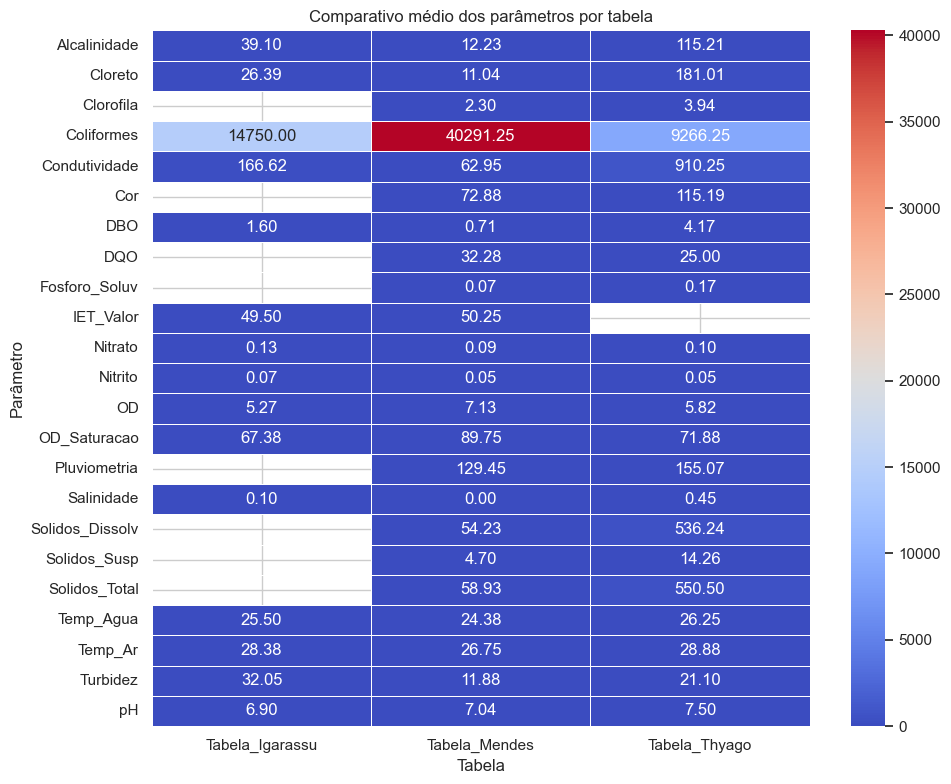

In [17]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    comparativo_media,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Comparativo médio dos parâmetros por tabela")
plt.xlabel("Tabela")
plt.ylabel("Parâmetro")
plt.tight_layout()
plt.show()

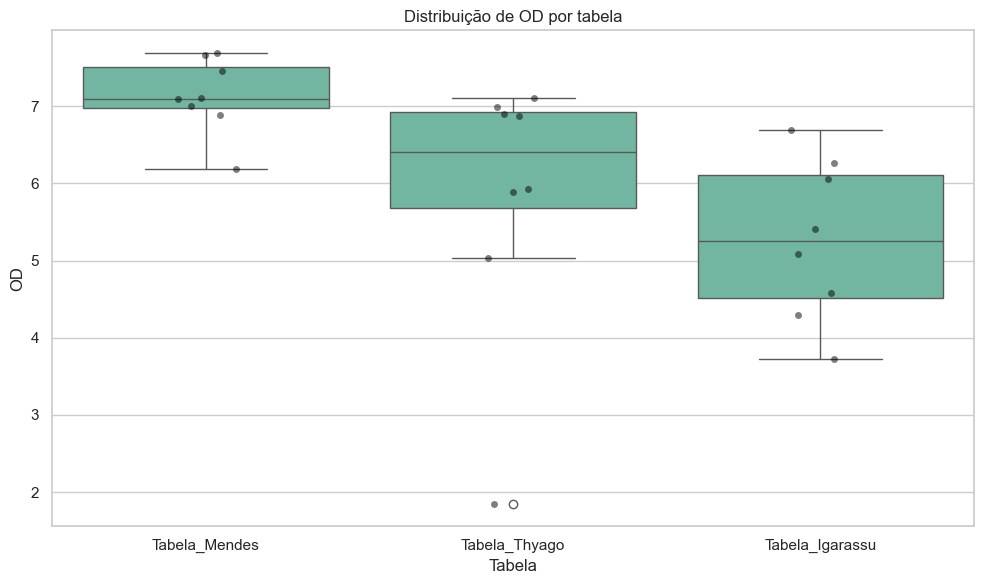

In [18]:
param = "OD"

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_final[df_final["Parametro"] == param],
    x="Tabela",
    y="Valor"
)

sns.stripplot(
    data=df_final[df_final["Parametro"] == param],
    x="Tabela",
    y="Valor",
    color="black",
    alpha=0.5
)

plt.title(f"Distribuição de {param} por tabela")
plt.xlabel("Tabela")
plt.ylabel(param)
plt.tight_layout()
plt.show()

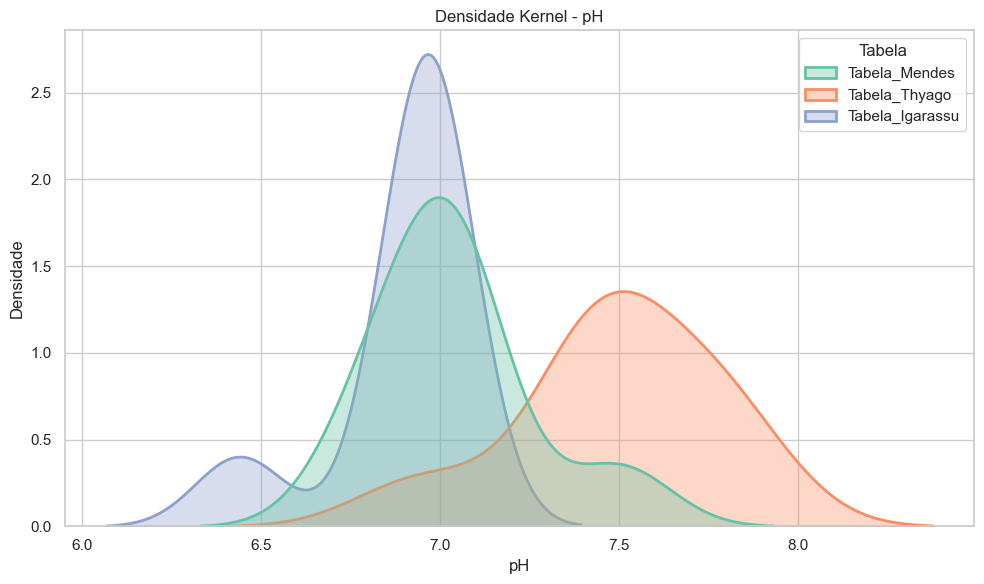

In [19]:
param = "pH"

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_final[df_final["Parametro"] == param],
    x="Valor",
    hue="Tabela",
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=2
)

plt.title(f"Densidade Kernel - {param}")
plt.xlabel(param)
plt.ylabel("Densidade")
plt.tight_layout()
plt.show()

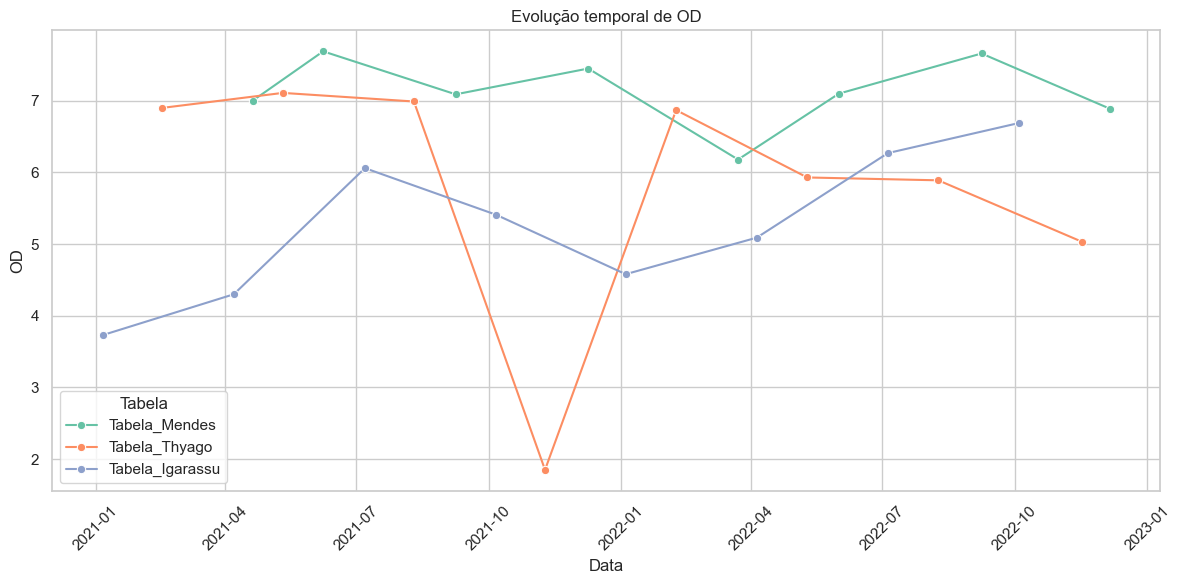

In [20]:
param = "OD"

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_final[df_final["Parametro"] == param],
    x="Data",
    y="Valor",
    hue="Tabela",
    marker="o"
)

plt.title(f"Evolução temporal de {param}")
plt.xlabel("Data")
plt.ylabel(param)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

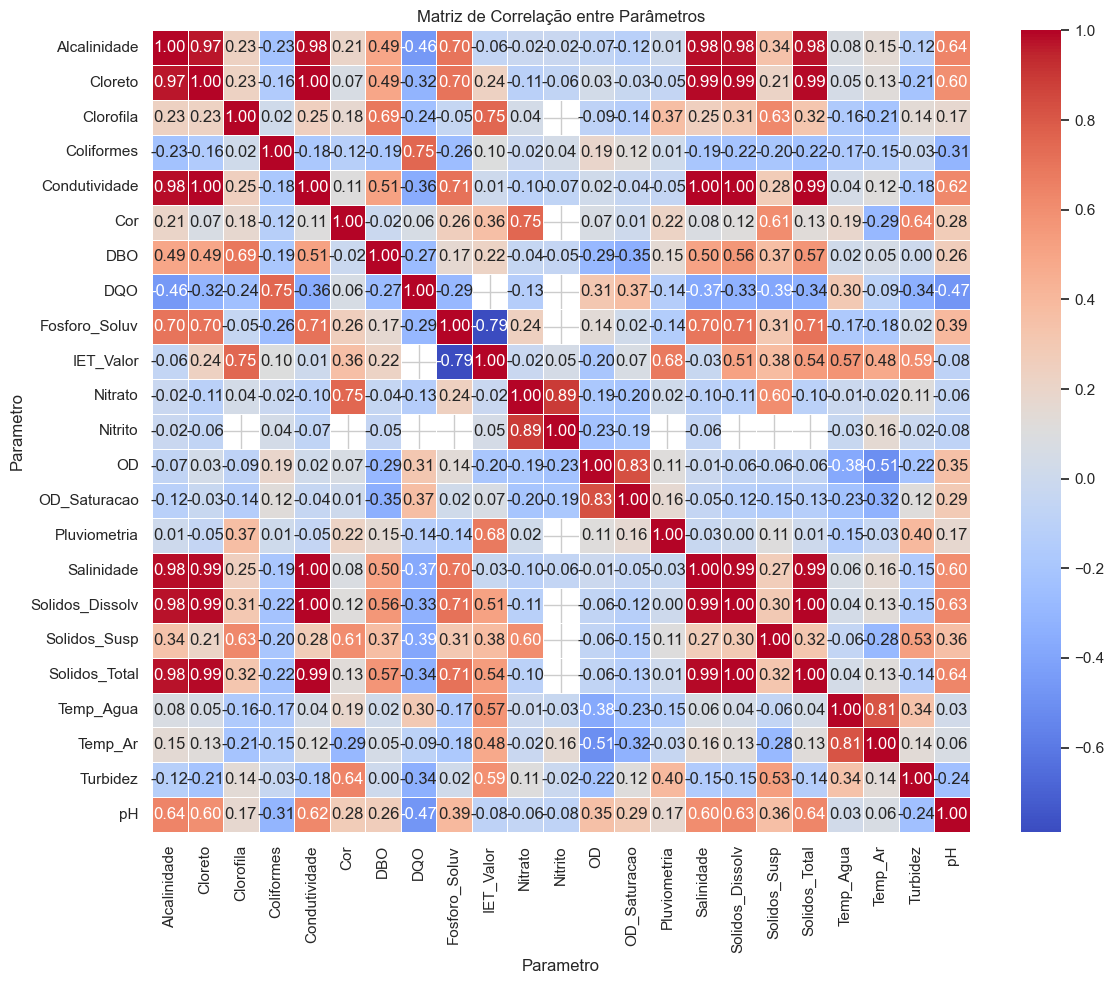

In [21]:
df_corr = df_final.pivot_table(
    index=["Tabela", "Data"],
    columns="Parametro",
    values="Valor"
)

correlacao = df_corr.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação entre Parâmetros")
plt.tight_layout()
plt.show()

In [23]:
df_final.to_excel("base_tratada_final.xlsx", index=False)
resumo_estatistico.to_excel("resumo_estatistico.xlsx")
comparativo_media.to_excel("comparativo_medias.xlsx")
